In [1]:
# =====================================================================
#  Fig. 2
# =====================================================================
import math
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt

FAST          = True
SNR_DB        = np.arange(-14.0, 4.0, 1.0)
KNEE_DB       = (-8.0, 2.0)                 # knee region
K             = 8                           # ANE K=8
# --- Algorithm 1---
ALPHA_GRID    = np.array([0.0, 0.15, 0.3, 0.45, 0.6, 0.8,
                          1.0, 1.5, 2.2, 3.0, 4.0])
TRAIN_L       = 3000  if FAST else 40000
TRAIN_L_KNEE  = 12000 if FAST else 60000
REFINE        = True
REFINE_DB     = (-8.0, 3.0)
REFINE_ITERS  = 15    if FAST else 80
VAL_FRAC      = 1.0
SIG_Z         = 3.0                         # 显著性门槛 z_sig
MIN_REL_GAIN  = 0.02                        # 实际增益下限 delta
MAX_NORM_SIG  = 4.0                         # ||z_k|| <= beta * sigma_v, beta=4
ZERO_MEAN     = True                        # 零质心约束

# --- 网格 ---
GRID_NLS      = 1024                        # 粗搜索网格点数
GRID_MMSE     = 2048  if FAST else 8192     # MMSE 后验积分网格
NEWTON_STEPS  = 3

# --- 自适应蒙特卡洛评价（含标准误 + 稀有事件保护）---
MC_BATCH_PT   = 10000                       # PyTorch 并行处理的 Batch Size
MC_MAX        = 100000 if FAST else 400000
MC_TOL        = 0.05                        # 目标 SE(MSE)/MSE <= 5%
MC_MIN_OUT    = 10                          # 至少观测到的 NLS 异常事件数
TRIALS        = 4000  if FAST else 100000
TRIALS_KNEE   = 12000 if FAST else 200000

# =====================================================================
# =====================================================================
def project_bank(Z, sigma):
    """Pi_Omega: 零质心 + 逐支路范数封顶 (POCS 一次扫掠)"""
    if ZERO_MEAN:
        Z = Z - Z.mean(axis=0, keepdims=True)
    nrm = np.linalg.norm(Z, axis=1, keepdims=True)
    cap = MAX_NORM_SIG * sigma
    scl = np.where(nrm > cap, cap / np.maximum(nrm, 1e-12), 1.0)
    return Z * scl

def make_directions(K, N, seed=11):
    """居中并逐行归一化的高斯方向集 U (K x N)"""
    U = np.random.default_rng(seed).standard_normal((K, N))
    U -= U.mean(axis=0, keepdims=True)
    U /= np.linalg.norm(U, axis=1, keepdims=True)
    return U
# =====================================================================
#  模型
# =====================================================================
class Model:
    name        = "base"
    unit        = ""        
    ylim        = None      
    def sigma_of(self, gamma):        
        return 1.0 / np.sqrt(2.0 * gamma)# sigma_v of background Gaussian noise

class FrequencyModel(Model):
    name  = "(a) Frequency estimation"
    unit  = "rad"
    ylim  = (-15.0, 3.0)

    def __init__(self, N=32):
        self.N    = N
        self.nvec = np.arange(1, N + 1, dtype=float)
        self.lo, self.hi = 1e-4, np.pi - 1e-4
        self.PHI_GRID = np.linspace(1e-3, np.pi - 1e-3, GRID_NLS)
        self.S_GRID   = np.cos(np.outer(self.nvec, self.PHI_GRID))
        self.S_NORM2  = np.sum(self.S_GRID ** 2, axis=0)
        self.BIN      = self.PHI_GRID[1] - self.PHI_GRID[0]
        self.PHI_MMSE = np.linspace(0.0, np.pi, GRID_MMSE)
        self.S_MMSE   = np.cos(np.outer(self.nvec, self.PHI_MMSE))
        self.S_MMSE2  = np.sum(self.S_MMSE ** 2, axis=0)
        self.PARAM_MMSE = self.PHI_MMSE
        self.anom     = 2.0 * np.pi / N

    def gen(self, trials, sigma, rng):
        theta = rng.uniform(0.0, np.pi, size=trials)
        X = np.cos(np.outer(theta, self.nvec)) + sigma * rng.standard_normal((trials, self.N))
        return theta, X

    def H_dH(self, X, th):
        nt = np.outer(th, self.nvec)
        s_, c_ = np.sin(nt), np.cos(nt)
        H  = np.sum(self.nvec * s_ * (X - c_), axis=1)
        dH = np.sum(self.nvec ** 2 * (1.0 + c_ * (X - 2.0 * c_)), axis=1)
        return H, dH

    def dtheta_dx(self, X, th):
        nt = np.outer(th, self.nvec)
        s_, c_ = np.sin(nt), np.cos(nt)
        denom = np.sum(self.nvec ** 2 * (1.0 + c_ * (X - 2.0 * c_)), axis=1)
        denom = np.where(np.abs(denom) > 1e-6, denom, np.sign(denom + 1e-12) * 1e-6)
        return -(self.nvec[None, :] * s_) / denom[:, None]


class DelayModel(Model):
    name  = "(b) Time-delay estimation"
    unit  = "samples"
    ylim  = None

    def __init__(self, N=64, sig_g=5.0, fc=0.2, tau_lo=18.0, tau_hi=46.0):
        self.N     = N
        self.nvec  = np.arange(1, N + 1, dtype=float)
        self.sig_g = float(sig_g)
        self.wc    = 2.0 * np.pi * fc
        self.lo, self.hi = float(tau_lo), float(tau_hi)
        tau0 = 0.5 * (self.lo + self.hi)
        raw = self._raw(np.array([tau0]))[:, 0]
        self.A = math.sqrt((N / 2.0) / max(float(np.sum(raw ** 2)), 1e-12))
        self.TAU_GRID = np.linspace(self.lo, self.hi, GRID_NLS)
        self.S_GRID   = self._template(self.TAU_GRID)
        self.S_NORM2  = np.sum(self.S_GRID ** 2, axis=0)
        self.BIN      = self.TAU_GRID[1] - self.TAU_GRID[0]
        self.TAU_MMSE = np.linspace(self.lo, self.hi, GRID_MMSE)
        self.S_MMSE   = self._template(self.TAU_MMSE)
        self.S_MMSE2  = np.sum(self.S_MMSE ** 2, axis=0)
        self.PARAM_MMSE = self.TAU_MMSE
        self.anom     = np.pi / self.wc

    def _raw(self, taus):
        u = self.nvec[:, None] - np.asarray(taus)[None, :]
        g = np.exp(-(u ** 2) / (2.0 * self.sig_g ** 2))
        return g * np.cos(self.wc * u)

    def _template(self, taus):
        return self.A * self._raw(taus)

    def gen(self, trials, sigma, rng):
        tau = rng.uniform(self.lo, self.hi, size=trials)
        u = self.nvec[None, :] - tau[:, None]
        g = np.exp(-(u ** 2) / (2.0 * self.sig_g ** 2))
        s = self.A * g * np.cos(self.wc * u)
        X = s + sigma * rng.standard_normal((trials, self.N))
        return tau, X

    def _s_and_stau(self, X, th):
        u  = self.nvec[None, :] - th[:, None]
        g  = np.exp(-(u ** 2) / (2.0 * self.sig_g ** 2))
        cs = np.cos(self.wc * u)
        sn = np.sin(self.wc * u)
        s     = self.A * g * cs
        s_tau = self.A * g * ((u / self.sig_g ** 2) * cs + self.wc * sn)
        return s, s_tau

    def H_dH(self, X, th):
        s, s_tau = self._s_and_stau(X, th)
        H  = -np.sum(s_tau * (X - s), axis=1)
        dH =  np.sum(s_tau ** 2, axis=1)
        return H, dH

    def dtheta_dx(self, X, th):
        s, s_tau = self._s_and_stau(X, th)
        denom = np.sum(s_tau ** 2, axis=1)
        denom = np.where(denom > 1e-9, denom, 1e-9)
        return s_tau / denom[:, None]


# =====================================================================
#  nls / mmse / grad / ane
# =====================================================================
def nls_batch(model, X):
    cost = -2.0 * (X @ model.S_GRID) + model.S_NORM2[None, :]
    th = model.PARAM_GRID_[np.argmin(cost, axis=1)] if hasattr(model, "PARAM_GRID_") \
         else (model.PHI_GRID if hasattr(model, "PHI_GRID") else model.TAU_GRID)[np.argmin(cost, axis=1)]
    for _ in range(NEWTON_STEPS):
        H, dH = model.H_dH(X, th)
        step = np.where(np.abs(dH) > 1e-9, H / np.where(np.abs(dH) > 1e-9, dH, 1e-9), 0.0)
        step = np.clip(step, -2.0 * model.BIN, 2.0 * model.BIN)
        th = np.clip(th - step, model.lo, model.hi)
    return th

def ane_batch(model, X, Z, th_plain=None):
    K = Z.shape[0]
    if np.allclose(Z, 0.0):
        th = nls_batch(model, X) if th_plain is None else th_plain
        return th.copy(), np.repeat(th[:, None], K, axis=1)
    outs = np.stack([nls_batch(model, X + Z[k][None, :]) for k in range(K)], axis=1)
    return outs.mean(axis=1), outs

def objective(model, Z, X, theta, th_plain):
    pred, _ = ane_batch(model, X, Z, th_plain)
    return float(np.mean((pred - theta) ** 2))

def train_bank_at_snr(model, K, sigma, U, Z_warm, refine, L_fit, rng, tag=""):
    L_val = max(4000, int(VAL_FRAC * L_fit))
    theta_f, X_f = model.gen(L_fit, sigma, rng)
    theta_v, X_v = model.gen(L_val, sigma, rng)
    thp_f = nls_batch(model, X_f)
    thp_v = nls_batch(model, X_v)
    plain_f = float(np.mean((thp_f - theta_f) ** 2))
    plain_v = float(np.mean((thp_v - theta_v) ** 2))

    best_Z, best = np.zeros((K, model.N)), plain_f
    for a in ALPHA_GRID[1:]:
        Z = project_bank(a * sigma * U, sigma)
        v = objective(model, Z, X_f, theta_f, thp_f)
        if v < best:
            best, best_Z = v, Z
    if Z_warm is not None and not np.allclose(Z_warm, 0.0):
        Z = project_bank(Z_warm, sigma)
        v = objective(model, Z, X_f, theta_f, thp_f)
        if v < best:
            best, best_Z = v, Z

    if refine and best < plain_f:
        Z, cur = best_Z.copy(), best
        lr = 0.5 * sigma
        for _ in range(REFINE_ITERS):
            pred, outs = ane_batch(model, X_f, Z)
            r = pred - theta_f
            Gz = np.zeros_like(Z)
            for k in range(K):
                gk = model.dtheta_dx(X_f + Z[k][None, :], outs[:, k])
                Gz[k] = (2.0 / L_fit / K) * (r[:, None] * gk).sum(axis=0)
            gn = np.max(np.abs(Gz))
            if gn < 1e-12:
                break
            accepted = False
            for _try in range(6):
                Zc = project_bank(Z - (lr / gn) * Gz, sigma)
                vc = objective(model, Zc, X_f, theta_f, thp_f)
                if vc < cur:
                    Z, cur, accepted = Zc, vc, True
                    lr *= 1.3
                    break
                lr *= 0.5
            if not accepted or lr < 1e-3 * sigma:
                break
        if cur < best:
            best, best_Z = cur, Z

    status, gain_v = "zero", 0.0
    if best < plain_f and not np.allclose(best_Z, 0.0):
        pred_v, _ = ane_batch(model, X_v, best_Z, thp_v)
        ev, ep = pred_v - theta_v, thp_v - theta_v
        d = ev * ev - ep * ep
        se = float(d.std(ddof=1)) / math.sqrt(L_val)
        t_ok = float(d.mean()) < -SIG_Z * se
        Bp, Ba = np.abs(ep) > model.anom, np.abs(ev) > model.anom
        n10 = int(np.sum(Bp & ~Ba))
        n01 = int(np.sum(~Bp & Ba))
        mc_ok = (n10 - n01) / math.sqrt(max(n10 + n01, 1)) > SIG_Z
        gain_v = 100.0 * (plain_v - float(np.mean(ev * ev))) / plain_v
        if (t_ok or mc_ok) and gain_v >= 100.0 * MIN_REL_GAIN:
            status = "accepted(" + ("t" if t_ok else "mc") + ")"
        else:
            best_Z, gain_v, status = np.zeros((K, model.N)), 0.0, "rejected(ns)"
    a_eff = float(np.mean(np.linalg.norm(best_Z, axis=1))) / sigma
    print(f"  [{tag}] plain {plain_v:.3e} | val-gain {gain_v:+5.1f}% | "
          f"spread {a_eff:4.2f} | {status}")
    return best_Z

def train_all_snr(model, gam, knee, seed0):
    U = make_directions(K, model.N, seed=11 + K)
    banks = [None] * len(SNR_DB)
    Zw, prev_sigma = None, None
    print(f"== {model.name}: 逐 SNR 训练 ANE bank (K={K}) ==")
    for i, gdb in enumerate(SNR_DB):
        sigma = model.sigma_of(gam[i])
        if Zw is not None and prev_sigma is not None:
            Zw = Zw * (sigma / prev_sigma)
        L_fit = TRAIN_L_KNEE if knee[i] else TRAIN_L
        refine = REFINE and (REFINE_DB[0] <= gdb <= REFINE_DB[1])
        banks[i] = train_bank_at_snr(model, K, sigma, U, Zw, refine, L_fit,
                                     np.random.default_rng(seed0 + i),
                                     tag=f"{model.unit} {gdb:+5.1f}dB")
        Zw, prev_sigma = banks[i], sigma
    return banks


# =====================================================================
#  PyTorch 自适应 MC
# =====================================================================
class PyTorchEvaluator:
    def __init__(self, model, device=None):
        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else 
                                       ("mps" if torch.backends.mps.is_available() else "cpu"))
        else:
            self.device = torch.device(device)
            
        self.name = model.name
        self.is_freq = hasattr(model, 'PHI_GRID')
        self.lo, self.hi = model.lo, model.hi
        self.anom = model.anom
        self.BIN = model.BIN
        self.N = model.N
        
        self.nvec = torch.tensor(model.nvec, device=self.device, dtype=torch.float32)
        self.S_GRID = torch.tensor(model.S_GRID, device=self.device, dtype=torch.float32)
        self.S_NORM2 = torch.tensor(model.S_NORM2, device=self.device, dtype=torch.float32)
        
        grid_param = model.PHI_GRID if self.is_freq else model.TAU_GRID
        self.PARAM_GRID = torch.tensor(grid_param, device=self.device, dtype=torch.float32)
        
        self.S_MMSE = torch.tensor(model.S_MMSE, device=self.device, dtype=torch.float32)
        self.S_MMSE2 = torch.tensor(model.S_MMSE2, device=self.device, dtype=torch.float32)
        self.PARAM_MMSE = torch.tensor(model.PARAM_MMSE, device=self.device, dtype=torch.float32)
        
        if not self.is_freq:
            self.sig_g = model.sig_g
            self.wc = model.wc
            self.A = model.A

    def gen_batch(self, batch_size, sigma):
        if self.is_freq:
            theta = torch.rand(batch_size, device=self.device) * math.pi
            nt = theta.unsqueeze(1) * self.nvec.unsqueeze(0)
            s = torch.cos(nt)
        else:
            theta = torch.rand(batch_size, device=self.device) * (self.hi - self.lo) + self.lo
            u = self.nvec.unsqueeze(0) - theta.unsqueeze(1)
            g = torch.exp(-(u ** 2) / (2.0 * self.sig_g ** 2))
            s = self.A * g * torch.cos(self.wc * u)
            
        noise = torch.randn(batch_size, self.N, device=self.device) * sigma
        X = s + noise
        return theta, X

    def H_dH(self, X, th):
        if self.is_freq:
            nt = th.unsqueeze(1) * self.nvec.unsqueeze(0)
            s_, c_ = torch.sin(nt), torch.cos(nt)
            H = torch.sum(self.nvec * s_ * (X - c_), dim=1)
            dH = torch.sum((self.nvec ** 2) * (1.0 + c_ * (X - 2.0 * c_)), dim=1)
        else:
            u = self.nvec.unsqueeze(0) - th.unsqueeze(1)
            g = torch.exp(-(u ** 2) / (2.0 * self.sig_g ** 2))
            cs = torch.cos(self.wc * u)
            sn = torch.sin(self.wc * u)
            s = self.A * g * cs
            s_tau = self.A * g * ((u / self.sig_g ** 2) * cs + self.wc * sn)
            H = -torch.sum(s_tau * (X - s), dim=1)
            dH = torch.sum(s_tau ** 2, dim=1)
        return H, dH

    def nls_batch(self, X):
        cost = -2.0 * torch.matmul(X, self.S_GRID) + self.S_NORM2.unsqueeze(0)
        idx = torch.argmin(cost, dim=1)
        th = self.PARAM_GRID[idx]
        
        for _ in range(NEWTON_STEPS): 
            H, dH = self.H_dH(X, th)
            dH_safe = torch.where(torch.abs(dH) > 1e-9, dH, torch.sign(dH + 1e-12) * 1e-9)
            step = H / dH_safe
            step = torch.where(torch.abs(dH) > 1e-9, step, torch.zeros_like(step))
            step = torch.clamp(step, -2.0 * self.BIN, 2.0 * self.BIN)
            th = torch.clamp(th - step, self.lo, self.hi)
        return th

    def mmse_batch(self, X, sigma):
        inv2s2 = 1.0 / (2.0 * sigma * sigma)
        log_w = (2.0 * torch.matmul(X, self.S_MMSE) - self.S_MMSE2.unsqueeze(0)) * inv2s2
        w = torch.nn.functional.softmax(log_w, dim=1)
        return torch.matmul(w, self.PARAM_MMSE)

    def ane_batch(self, X, Z_tensor):
        K = Z_tensor.shape[0]
        if torch.allclose(Z_tensor, torch.zeros_like(Z_tensor)):
            return self.nls_batch(X)
        preds = torch.stack([self.nls_batch(X + Z_tensor[k].unsqueeze(0)) for k in range(K)], dim=1)
        return preds.mean(dim=1)


def run_model_pytorch(model, banks, gam, knee):
    pt_eval = PyTorchEvaluator(model)
    print(f"\n== {model.name}: 自适应 MC 评价 (Powered by PyTorch on {pt_eval.device}) ==")
    
    out = {"mse_mmse": [], "mse_mmse_se": [],
           "mse_nls": [], "mse_nls_se": [],
           "mse_ane": [], "mse_ane_se": []}
    TRACK = ["nls", "mmse", "ane"]

    def _upd_pt(acc, name, e_tensor):
        e_sq = e_tensor * e_tensor
        a = acc.setdefault(name, [0.0, 0.0, 0, 0])
        a[0] += float(e_sq.sum().item())
        a[1] += float((e_sq * e_sq).sum().item())
        a[2] += int(e_tensor.numel())
        a[3] += int((torch.abs(e_tensor) > pt_eval.anom).sum().item())

    def _mse_se(a):
        n = max(a[2], 1)
        m = a[0] / n
        v = max(a[1] / n - m * m, 0.0)
        return m, math.sqrt(v / n), a[3] / n

    for i, gdb in enumerate(SNR_DB):
        sigma = model.sigma_of(gam[i])
        n_min = TRIALS_KNEE if knee[i] else TRIALS
        
        if banks[i] is not None:
            Z_pt = torch.tensor(banks[i], device=pt_eval.device, dtype=torch.float32)
        else:
            Z_pt = torch.zeros((K, model.N), device=pt_eval.device, dtype=torch.float32)
            
        acc, total, converged = {}, 0, False
        
        while total < MC_MAX:
            b = int(min(MC_BATCH_PT, MC_MAX - total))
            theta, X = pt_eval.gen_batch(b, sigma)
            
            th_nls = pt_eval.nls_batch(X)
            _upd_pt(acc, "nls", th_nls - theta)
            
            th_mmse = pt_eval.mmse_batch(X, sigma)
            _upd_pt(acc, "mmse", th_mmse - theta)
            
            th_ane = pt_eval.ane_batch(X, Z_pt)
            _upd_pt(acc, "ane", th_ane - theta)
            
            total += b
            
            if total >= n_min:
                converged = acc["nls"][3] >= MC_MIN_OUT
                if converged:
                    for nm in TRACK:
                        m_, se_, _ = _mse_se(acc[nm])
                        if m_ > 0.0 and se_ > MC_TOL * m_:
                            converged = False; break
                if converged:
                    break
                    
        m_n, se_n, an_n = _mse_se(acc["nls"])
        m_m, se_m, _    = _mse_se(acc["mmse"])
        m_a, se_a, _    = _mse_se(acc["ane"])
        
        out["mse_nls"].append(m_n);  out["mse_nls_se"].append(se_n)
        out["mse_mmse"].append(m_m); out["mse_mmse_se"].append(se_m)
        out["mse_ane"].append(m_a);  out["mse_ane_se"].append(se_a)
        
        flag = " " if converged else "*"
        print(f"SNR {gdb:6.1f} dB | n={total:6d}{flag}| NLS {m_n:.3e} | "
              f"ANE {m_a:.3e} | MMSE {m_m:.3e} | outNLS {acc['nls'][3]:d}")
              
    for k in out:
        out[k] = np.asarray(out[k], float)
    return out

In [ ]:
# =====================================================================
##Plot Fig 2
# =====================================================================
gam  = 10 ** (SNR_DB / 10.0)
knee = (SNR_DB >= KNEE_DB[0]) & (SNR_DB <= KNEE_DB[1])

models = {
    "freq": FrequencyModel(N=32),
    "tde":  DelayModel(N=64, sig_g=5.0, fc=0.2, tau_lo=18.0, tau_hi=46.0),
}

results = {}
for key, mdl in models.items():
    banks = train_all_snr(mdl, gam, knee, seed0=500 + 13 * K)
    # 调用基于 PyTorch 的加速引擎
    results[key] = run_model_pytorch(mdl, banks, gam, knee)

# 存盘
flat = {"snr_db": SNR_DB}
for key in results:
    for f in results[key]:
        flat[f"{key}_{f}"] = results[key][f]
np.savez("fig2_results.npz", **flat)

# -------------------- 双子图出版图 (Fig. 2) --------------------
try:
    import scienceplots  # noqa: F401
    plt.style.use(["science", "ieee"])
    matplotlib.rcParams["font.serif"] = ["Times New Roman"]
    matplotlib.rcParams["axes.unicode_minus"] = False
except Exception:
    pass  # 未装 scienceplots 时退化为默认样式

dB = lambda v: 10.0 * np.log10(np.maximum(v, 1e-12))

fig, axes = plt.subplots(1, 2, figsize=(7.16, 2.85))
for ax, key in zip(axes, ["freq", "tde"]):
    r, mdl = results[key], models[key]
    ax.plot(SNR_DB, dB(r["mse_mmse"]), color="k",        ls="-",  lw=1.0,
            marker=None, zorder=5, label=r"$\hat\theta_{\mathrm{MMSE}}$")
    ax.plot(SNR_DB, dB(r["mse_nls"]),  color="tab:red",  ls=":",  lw=1.0,
            marker="*", ms=2.5, zorder=4, label=r"$\hat\theta_{\mathrm{MAP}}$")
    ax.plot(SNR_DB, dB(r["mse_ane"]),  color="tab:blue", ls="--", lw=1.0,
            marker="o", ms=2.5, zorder=4, label=rf"$\hat\theta_{{\mathrm{{ANE}}}}\ (K={K})$")
    
    ax.set_xlabel(r"SNR $\gamma$ (dB)")
    ax.set_xlim([SNR_DB.min() - 0.5, SNR_DB.max() + 0.5])
    if mdl.ylim is not None:
        ax.set_ylim(mdl.ylim)
    ax.set_title(mdl.name, fontsize=9)
    ax.grid(ls=":", alpha=0.6)
    
axes[0].set_ylabel(r"$10\log_{10}$ MSE (dB)")
axes[0].legend(fontsize=7, loc="upper right")

fig.tight_layout()
fig.savefig("Fig2.pdf", bbox_inches="tight")
print("\nSaved Fig2.pdf and fig2_results.npz")
plt.show()

== (a) Frequency estimation: 逐 SNR 训练 ANE bank (K=8) ==
  [rad -14.0dB] plain 1.439e+00 | val-gain +34.2% | spread 3.95 | accepted(t)
  [rad -13.0dB] plain 1.341e+00 | val-gain +35.7% | spread 3.95 | accepted(t)
  [rad -12.0dB] plain 1.197e+00 | val-gain +34.7% | spread 3.95 | accepted(t)
  [rad -11.0dB] plain 1.120e+00 | val-gain +33.7% | spread 3.95 | accepted(t)
  [rad -10.0dB] plain 9.840e-01 | val-gain +31.7% | spread 3.95 | accepted(t)
  [rad  -9.0dB] plain 8.191e-01 | val-gain +27.3% | spread 3.95 | accepted(t)
  [rad  -8.0dB] plain 7.393e-01 | val-gain +29.2% | spread 3.96 | accepted(t)
  [rad  -7.0dB] plain 5.689e-01 | val-gain +27.2% | spread 3.03 | accepted(t)
  [rad  -6.0dB] plain 4.257e-01 | val-gain +25.8% | spread 2.55 | accepted(t)
  [rad  -5.0dB] plain 2.767e-01 | val-gain +22.7% | spread 2.20 | accepted(t)
  [rad  -4.0dB] plain 1.586e-01 | val-gain +19.9% | spread 1.49 | accepted(t)
  [rad  -3.0dB] plain 7.446e-02 | val-gain +17.0% | spread 1.50 | accepted(t)
  [rad  

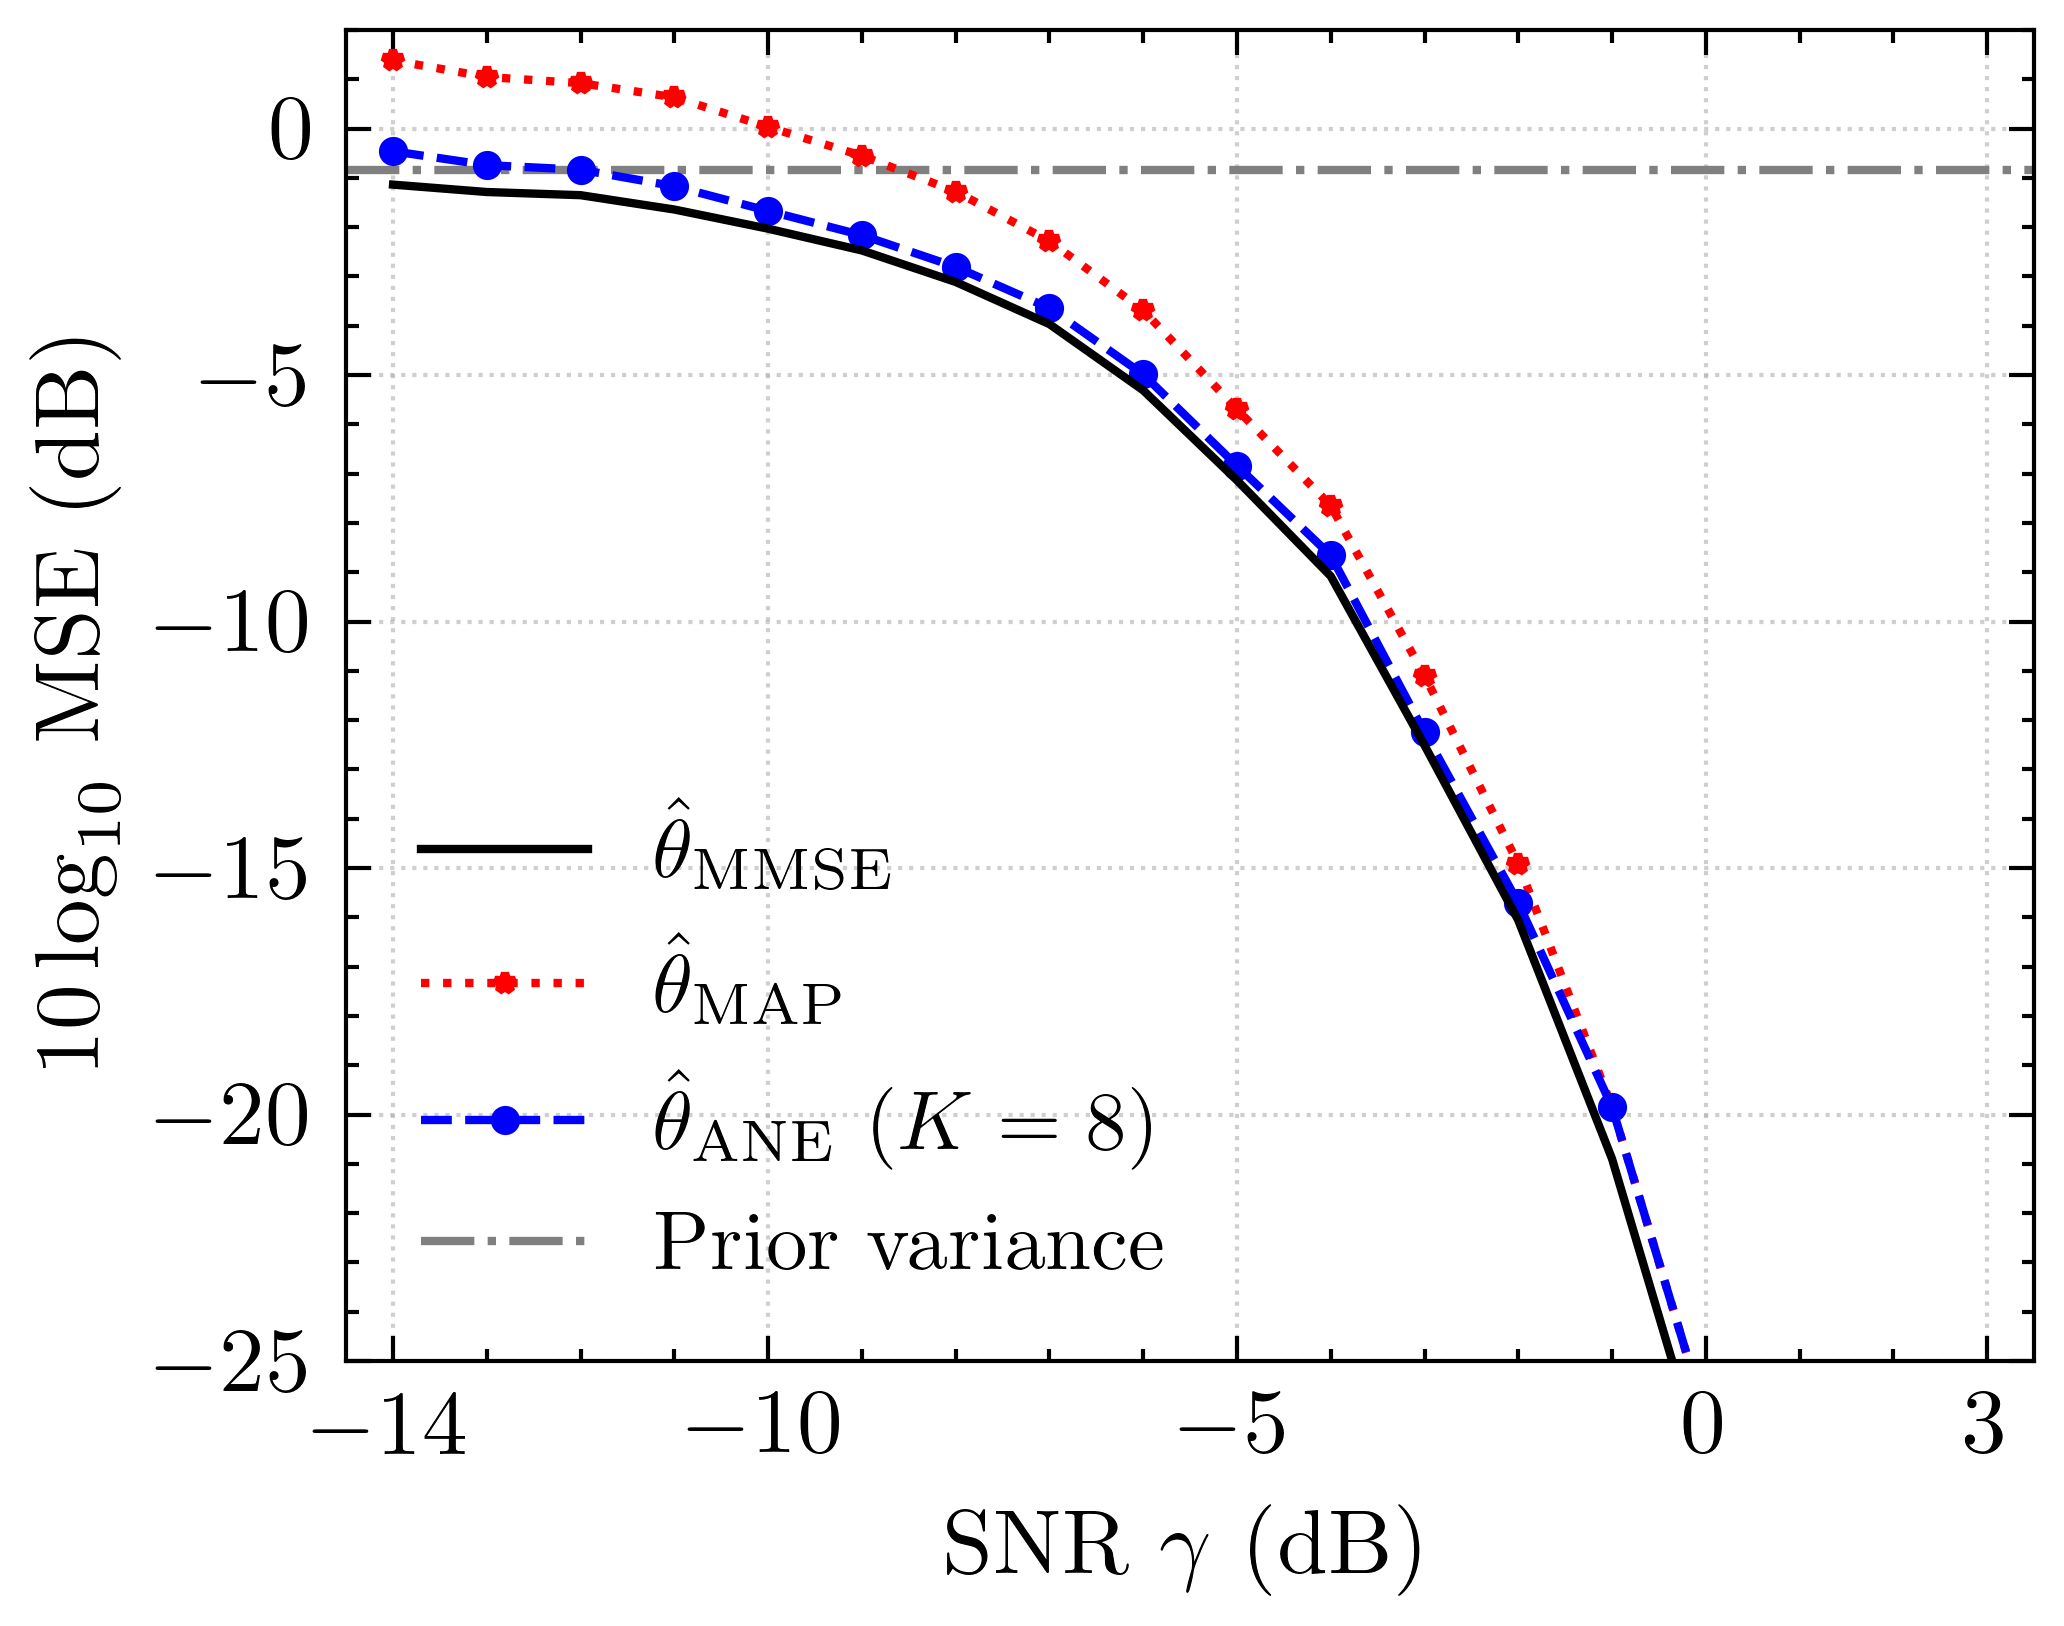

In [7]:
fig, ax = plt.subplots(figsize=(3.58, 2.85))

key = "freq"
r, mdl = results[key], models[key]

ax.plot(SNR_DB, dB(r["mse_mmse"]),
        color="k", ls="-", lw=1.0,
        marker=None, zorder=5,
        label=r"$\hat\theta_{\mathrm{MMSE}}$")

ax.plot(SNR_DB, dB(r["mse_nls"]),
        color="r", ls=":", lw=1.0,
        marker="*", ms=2.5, zorder=4,
        label=r"$\hat\theta_{\mathrm{MAP}}$")

ax.plot(SNR_DB, dB(r["mse_ane"]),
        color="b", ls="--", lw=1.0,
        marker="o", ms=2.5, zorder=4,
        label=rf"$\hat\theta_{{\mathrm{{ANE}}}}\ (K={K})$")

PRIOR_FLOOR_FREQ = 10*np.log10(np.pi**2/12)

ax.axhline(PRIOR_FLOOR_FREQ,
           color="gray",
           ls="-.",
           lw=1.0,
           label=r"Prior variance")

ax.set_xlabel(r"SNR $\gamma$ (dB)",fontsize=11)
ax.set_ylabel(r"$10\log_{10}$ MSE (dB)",fontsize=11)

ax.set_xlim([SNR_DB.min() - 0.5, SNR_DB.max() + 0.5])

ax.set_xticks([-14, -12, -10, -8,,-6, -4, 0, 3])
ax.set_ylim([-25,2])
ax.tick_params(axis='both', labelsize=11)
ax.grid(ls=":", alpha=0.6)
ax.legend(fontsize=10, loc="lower left")

plt.tight_layout()
fig.savefig("D:/Fig2.pdf")
plt.show()